# Basic Multilayer Perceptron Accuracy

 Building a Multilayer Perceptron (MLP) model with Keras

In [379]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from tensorflow.keras.callbacks import EarlyStopping

In [380]:
mlp_X_train = X_train
mlp_y_train = y_train
mlp_X_test = X_test
mlp_y_test = y_test
mlp_X_val = X_val
mlp_y_val = y_val

In [381]:
# Define the model
mlp = Sequential()

# Specify the input shape in the first layer to match the shape of your input data
mlp.add(Flatten(input_shape=(mlp_X_train.shape[1], mlp_X_train.shape[2], mlp_X_train.shape[3])))

# Adding Dense layers and output layer
mlp.add(Dense(512, activation='relu'))
mlp.add(Dense(512, activation='relu'))
mlp.add(Dense(256, activation='relu'))
mlp.add(Dense(256, activation='relu'))
mlp.add(Dense(128, activation='relu'))

mlp.add(Dense(6, activation='softmax'))

In [382]:
# Use early_stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Compile the model
mlp.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
mlp.summary()

Model: "sequential_47"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_49 (Flatten)        (None, 49152)             0         
                                                                 
 dense_241 (Dense)           (None, 512)               25166336  
                                                                 
 dense_242 (Dense)           (None, 512)               262656    
                                                                 
 dense_243 (Dense)           (None, 256)               131328    
                                                                 
 dense_244 (Dense)           (None, 256)               65792     
                                                                 
 dense_245 (Dense)           (None, 128)               32896     
                                                                 
 dense_246 (Dense)           (None, 6)               

In [383]:
# Convert labels to one-hot encoded format
mlp_y_train_encoded = to_categorical(mlp_y_train)
mlp_y_test_encoded = to_categorical(mlp_y_test)

In [384]:
# Train the model with early stopping
history = mlp.fit(mlp_X_train, mlp_y_train_encoded, epochs=64, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = mlp.evaluate(mlp_X_test, mlp_y_test_encoded)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/64


21/21 [==============================] - 2s 52ms/step - loss: 9.8065 - accuracy: 0.1741 - val_loss: 3.6166 - val_accuracy: 0.1964
Epoch 2/64
21/21 [==============================] - 1s 42ms/step - loss: 2.2812 - accuracy: 0.1994 - val_loss: 1.9294 - val_accuracy: 0.2024
Epoch 3/64
21/21 [==============================] - 1s 40ms/step - loss: 2.0498 - accuracy: 0.2247 - val_loss: 1.9530 - val_accuracy: 0.1607
Epoch 4/64
21/21 [==============================] - 1s 42ms/step - loss: 1.8268 - accuracy: 0.2292 - val_loss: 1.8206 - val_accuracy: 0.2083
Epoch 5/64
21/21 [==============================] - 1s 42ms/step - loss: 1.6890 - accuracy: 0.2827 - val_loss: 1.7606 - val_accuracy: 0.2500
Epoch 6/64
21/21 [==============================] - 1s 42ms/step - loss: 1.6689 - accuracy: 0.2946 - val_loss: 1.7283 - val_accuracy: 0.2738
Epoch 7/64
21/21 [==============================] - 1s 40ms/step - loss: 1.6196 - accuracy: 0.3274 - val_loss: 1.7656 - val_accuracy: 0.2202
Epoch 8/64
21/21 [======

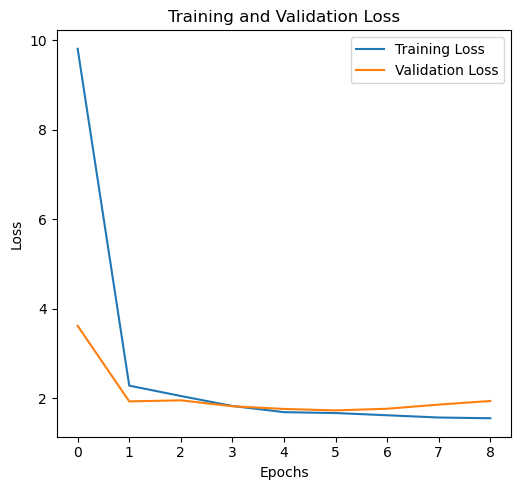

In [385]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()